# Исследование коэффициентов корреляции

# Постановка задачи

1. **Генерация данных:** Сгенерировать две независимые выборки объемом 1000: $X \sim N(0; 1)$ и $Z \sim N(5; 2)$.
2. **Расчет зависимостей:** Для каждой пары $(x, z)$ вычислить $y$ тремя способами:
    * **Линейная зависимость:** $Y = aX + (1-a)Z$ для $a \in \{0, 0.25, 0.5, 0.75, 1\}$.
    * **Кубическая зависимость:** $Y = 0.05X^3 + 4Z$.
    * **Квадратичная зависимость:** $Y = X^2 + Z$.
3. **Анализ выбросов:** Добавить аномальные значения к линейной (при $a=0.5$) и кубической зависимостям. Проанализировать влияние выбросов на значения коэффициентов.
4. **Статистический анализ:** Для всех трех зависимостей (до и после добавления выбросов) рассчитать коэффициенты корреляции Пирсона, Спирмена и Кендалла. Проверить гипотезу о равенстве коэффициентов нулю на уровне значимости $\alpha = 0.05$.

---

# Теоретическая часть

## Коэффициент корреляции Пирсона
Измеряет силу и направление **линейной** связи между двумя непрерывными переменными:

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

* **Интервал:** $[-1, 1]$.
* $r = 1$ — строгая прямая линейная связь.
* $r = 0$ — отсутствие линейной связи (при этом нелинейная зависимость может существовать).

--- 

## Коэффициент корреляции Спирмена
Ранговый коэффициент, оценивающий, насколько хорошо связь между переменными может быть описана с помощью **монотонной** функции:

$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

где $d_i$ — разность между рангами $x_i$ и $y_i$. В отличие от коэффициента Пирсона, он устойчив к нелинейным монотонным преобразованиям и менее чувствителен к выбросам.

---

## Коэффициент корреляции Кендалла ($\tau$)
Основан на подсчете количества согласованных ($n_c$) и несогласованных ($n_d$) пар наблюдений. Считается наиболее **робастным** (устойчивым к аномалиям) методом:

$$\tau = \frac{n_c - n_d}{\frac{1}{2}n(n - 1)}$$

Коэффициент Кендалла эффективен при небольших выборках и наличии большого количества совпадающих рангов.

---
### Проверка гипотезы о значимости корреляции
Для проверки гипотезы $H_0: \text{коэффициент} = 0$ (отсутствие связи) используется значение $p$-value. 
* При уровне значимости **$\alpha = 0.05$** гипотеза $H_0$ отвергается, если **$p\text{-value} < 0.05$**. В этом случае связь признается статистически значимой.

In [71]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Устанавливаем seed для воспроизводимости результатов
np.random.seed(42)

## 1.Генерация независимых выборок

Генерируем две независимые выборки размером 1000:
- X подчиняется нормальному распределению N(0,1) - стандартное нормальное
- Z подчиняется нормальному распределению N(5,2) - среднее 5, стандартное отклонение √2

In [72]:
# А. Генерация выборок
np.random.seed(42)
n = 1000
X = np.random.normal(0, 1, n)
Z = np.random.normal(5, 2, n)  # Используем std=2

print(f"Размер выборок: {n}")
print(f"X: среднее={X.mean():.3f}, std={X.std():.3f}")
print(f"Z: среднее={Z.mean():.3f}, std={Z.std():.3f}")

Размер выборок: 1000
X: среднее=0.019, std=0.979
Z: среднее=5.142, std=1.994


In [ ]:
def add_outliers(data, count=5):
    data_with_outliers = data.copy()
    idx = np.random.choice(n, count, replace=False)
    data_with_outliers[idx] = data_with_outliers[idx] + 50
    return data_with_outliers

## 2. Вычисление Y для трёх типов зависимостей

Для каждой пары (x,z) вычисляем Y по трём зависимостям:

1. **Линейная зависимость**: Y = aX + (1-a)Z
   - Параметр a контролирует вес X и Z
   - При a=0: Y=Z (полностью зависит от Z)
   - При a=1: Y=X (полностью зависит от X)
   - При a=0.5: равный вес обоих переменных

2. **Кубическая зависимость**: Y = 0.05X³ + 4Z
   - Нелинейная связь с X
   - Квадратичный коэффициент перед X³ ослабляет влияние нелинейности

3. **Квадратичная зависимость**: Y = X² + Z
   - Нелинейная связь с X через квадрат
   - Прямое влияние Z

In [ ]:
Y_cases = {}

# Линейные зависимости
for a in [0, 0.25, 0.5, 0.75, 1.0]:
    Y_cases[f'Linear (a={a})'] = a * X + (1 - a) * Z

# Кубическая зависимость
Y_cases['Cubic'] = 0.05 * (X**3) + 4 * Z

# Квадратичная зависимость
Y_cases['Quadratic'] = (X**2) + Z

## 3. Добавление выбросов

Добавляем выбросы к выбранным зависимостям для анализа их влияния на коэффициенты корреляции:
- К B1 (линейная зависимость с a=0.5)
- К B2 (кубическая зависимость)

Выбросы добавляются путём изменения нескольких значений Y на экстремально большие значения.

In [75]:
Y_cases['Linear (a=0.5) + Outliers'] = add_outliers(Y_cases['Linear (a=0.5)'])
Y_cases['Cubic + Outliers'] = add_outliers(Y_cases['Cubic'])

print("Данные для всех сценариев (включая выбросы) подготовлены.")

Данные для всех сценариев (включая выбросы) подготовлены.


## 4. Расчет коэффициентов корреляции и проверка гипотез

Для каждой зависимости рассчитываем три коэффициента корреляции:

1. **Корреляция Пирсона (r)**: Мера линейной связи
   - Диапазон: [-1, 1]
   - Чувствительна к выбросам
   - Наиболее известный и часто используемый

2. **Ранговая корреляция Спирмана (ρ)**: Мера монотонной связи
   - Основана на рангах данных
   - Более устойчива к выбросам, чем Пирсона
   - Хороша для нелинейных зависимостей

3. **Коэффициент Кендалла (τ)**: Мера ранговой согласованности
   - На основе пар согласованных и несогласованных наблюдений
   - Самый устойчивый к выбросам
   - Имеет лучшую статистическую интерпретацию

Для каждого коэффициента проверяем гипотезу H₀: r=0 (ρ=0, τ=0) на уровне значимости α=0.05.

In [76]:
def get_stats(x, y):
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    r_k, p_k = stats.kendalltau(x, y)
    
    format_p = lambda p: "< 0.001" if p < 0.001 else f"{p:.4f}"
    
    return r_p, format_p(p_p), r_s, format_p(p_s), r_k, format_p(p_k)


In [77]:

# ЛИНЕЙНАЯ ЗАВИСИМОСТЬ
print("Линейная зависимость Y = aX + (1 − a)Z")
a_values = [0, 0.25, 0.5, 0.75, 1.0]

for a in a_values:
    key = f"Linear (a={a})"
    if key in Y_cases:
        rp, pp, rs, ps, rk, pk = get_stats(X, Y_cases[key])
        
        mini_df = pd.DataFrame([
            ["Пирсон", round(rp, 4), pp],
            ["Спирмен", round(rs, 4), ps],
            ["Кендалл", round(rk, 4), pk]
        ], columns=['Критерий', 'Коэффициент', 'p-value'])
        
        print(f"\nПараметр a = {a}")
        display(mini_df)


Линейная зависимость Y = aX + (1 − a)Z

Параметр a = 0


,Критерий,Коэффициент,p-value
0,Пирсон,-0.0404,0.2018
1,Спирмен,-0.0638,0.0438
2,Кендалл,-0.0438,0.0380



Параметр a = 0.25


,Критерий,Коэффициент,p-value
0,Пирсон,0.1224,< 0.001
1,Спирмен,0.0909,0.0040
2,Кендалл,0.0601,0.0044



Параметр a = 0.5


,Критерий,Коэффициент,p-value
0,Пирсон,0.4110,< 0.001
1,Спирмен,0.3793,< 0.001
2,Кендалл,0.2580,< 0.001



Параметр a = 0.75


,Критерий,Коэффициент,p-value
0,Пирсон,0.8201,< 0.001
1,Спирмен,0.8098,< 0.001
2,Кендалл,0.6132,< 0.001



Параметр a = 1.0


,Критерий,Коэффициент,p-value
0,Пирсон,1.0,< 0.001
1,Спирмен,1.0,< 0.001
2,Кендалл,1.0,< 0.001


### Линейная зависимость $Y = aX + (1 - a)Z$
* При $a = 0$ ($Y = Z$) теоретически корреляция между $X$ и $Y$ должна отсутствовать. Коэффициент Пирсона подтверждает это, являясь статистически незначимым ($p \text{-value} > 0.05$).
* С ростом параметра $a$ (увеличением доли $X$ в итоговой выборке) все три коэффициента корреляции монотонно увеличиваются.
* При $a = 1$ ($Y = X$) наблюдается идеальная функциональная связь, при которой все коэффициенты корреляции принимают значение $1.0$.
* На уровне значимости $\alpha = 0.05$ гипотеза $H_0$ об отсутствии связи отвергается для всех случаев, кроме $a = 0$.

In [78]:
# КВАДРАТИЧНАЯ ЗАВИСИМОСТЬ
print("\nКвадратичная зависимость Y = X^2 + Z")
if 'Quadratic' in Y_cases:
    rp, pp, rs, ps, rk, pk = get_stats(X, Y_cases['Quadratic'])
    df_tab3 = pd.DataFrame([
        ["Пирсон", round(rp, 4), pp],
        ["Спирмен", round(rs, 4), ps],
        ["Кендалл", round(rk, 4), pk]
    ], columns=['Критерий', 'Коэффициент', 'p-value'])
    display(df_tab3)


Квадратичная зависимость Y = X^2 + Z


,Критерий,Коэффициент,p-value
0,Пирсон,0.0282,0.3729
1,Спирмен,-0.0221,0.4847
2,Кендалл,-0.0194,0.3583


#### Квадратичная зависимость $Y = X^2 + Z$

* Коэффициенты Пирсона, Спирмена и Кендалла близки к нулю, статистическая значимость отсутствует.
* **Причина:** Отсутствие корреляции объясняется немонотонным характером зависимости $X^2$ (функция убывает при $X < 0$ и возрастает при $X > 0$). Поскольку $X$ распределено симметрично относительно нуля, положительная и отрицательная корреляции «взаимно уничтожаются». 
* **Вывод:** Отсутствие линейной или ранговой корреляции не означает отсутствия зависимости между переменными.

In [79]:
# КУБИЧЕСКАЯ ЗАВИСИМОСТЬ
print("\nКубическая зависимость Y = 0.05X^3 + 4Z")
if 'Cubic' in Y_cases:
    rp, pp, rs, ps, rk, pk = get_stats(X, Y_cases['Cubic'])
    df_tab2 = pd.DataFrame([
        ["Пирсон", round(rp, 4), pp],
        ["Спирмен", round(rs, 4), ps],
        ["Кендалл", round(rk, 4), pk]
    ], columns=['Критерий', 'Коэффициент', 'p-value'])
    display(df_tab2)



Кубическая зависимость Y = 0.05X^3 + 4Z


,Критерий,Коэффициент,p-value
0,Пирсон,-0.0223,0.4805
1,Спирмен,-0.0500,0.1144
2,Кендалл,-0.0346,0.1011


#### Кубическая зависимость $Y = 0.05X^3 + 4Z$
* Все коэффициенты корреляции близки к нулю ($|r| < 0.05$), а значение $p \text{-value} > 0.05$ во всех случаях. Гипотеза об отсутствии корреляции не отвергается.
* **Причина:** Несмотря на наличие математической зависимости, «сигнал» $0.05X^3$ крайне слаб и полностью маскируется сильным шумом $Z$ с большой дисперсией. В данных условиях стандартные методы не фиксируют нелинейную связь.

In [ ]:
def get_full_analysis(x, y):
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    r_k, p_k = stats.kendalltau(x, y)
    
    f_p = lambda p: "< 0.001" if p < 0.001 else f"{p:.4f}"
    check_h0 = lambda p: "Отвергается" if p < 0.05 else "Не отвергается"
    
    return [
        [round(r_p, 4), f_p(p_p), check_h0(p_p)],
        [round(r_s, 4), f_p(p_s), check_h0(p_s)],
        [round(r_k, 4), f_p(p_k), check_h0(p_k)]
    ]

print("Анализ влияния выбросов на статистическую значимость")

# Список пар для сравнения: (Ключ_БЕЗ_выбросов, Ключ_С_выбросами, Название)
comparison_cases = [
    ('Linear (a=0.5)', 'Linear (a=0.5) + Outliers', 'Линейная зависимость (a=0.5)'),
    ('Cubic', 'Cubic + Outliers', 'Кубическая зависимость')
]

for base_key, outlier_key, title in comparison_cases:
    if base_key in Y_cases and outlier_key in Y_cases:
        print(f"\n--- {title} ---")
        
        base_stats = get_full_analysis(X, Y_cases[base_key])
        outlier_stats = get_full_analysis(X, Y_cases[outlier_key])
        
        df_impact = pd.DataFrame({
            "Критерий": ["Пирсон", "Спирмен", "Кендалл"],
            "Коэфф. (Без)": [base_stats[0][0], base_stats[1][0], base_stats[2][0]],
            "H0 (Без)": [base_stats[0][2], base_stats[1][2], base_stats[2][2]],
            "Коэфф. (Выбросы)": [outlier_stats[0][0], outlier_stats[1][0], outlier_stats[2][0]],
            "H0 (Выбросы)": [outlier_stats[0][2], outlier_stats[1][2], outlier_stats[2][2]]
        })
        
        df_impact['Изменение %'] = ((df_impact['Коэфф. (Выбросы)'] - df_impact['Коэфф. (Без)']) / df_impact['Коэфф. (Без)'] * 100).round(1)
        
        display(df_impact)

Анализ влияния выбросов на статистическую значимость

--- Линейная зависимость (a=0.5) ---


,Критерий,Коэфф. (Без),H0 (Без),Коэфф. (Выбросы),H0 (Выбросы),Изменение %
0,Пирсон,0.4110,Отвергается,0.1094,Отвергается,-73.4
1,Спирмен,0.3793,Отвергается,0.3744,Отвергается,-1.3
2,Кендалл,0.2580,Отвергается,0.2549,Отвергается,-1.2



--- Кубическая зависимость ---


,Критерий,Коэфф. (Без),H0 (Без),Коэфф. (Выбросы),H0 (Выбросы),Изменение %
0,Пирсон,-0.0223,Не отвергается,-0.0210,Не отвергается,-5.8
1,Спирмен,-0.0500,Не отвергается,-0.0515,Не отвергается,3.0
2,Кендалл,-0.0346,Не отвергается,-0.0356,Не отвергается,2.9


#### Влияние выбросов (Анализ робастности)

* **Линейная зависимость ($a=0.5$):** * **Коэффициент Пирсона** оказался крайне чувствительным: при добавлении всего нескольких аномальных точек его значение резко падает (на **70-80%**), что может привести к ложному выводу об отсутствии связи ($p \text{-value} > 0.05$).
    * **Ранговые коэффициенты (Спирмен и Кендалл)** продемонстрировали высокую **робастность** (устойчивость). Их значения изменились незначительно (менее 2%), так как они оперируют рангами, а не абсолютными величинами.


* **Кубическая зависимость:** * Влияние выбросов на коэффициент Пирсона здесь минимально (изменение около **5-6%**). Это объясняется тем, что из-за сильного зашумления выборки переменной $Z$ линейная связь изначально отсутствовала ($r \approx 0$). Выбросы в данном случае просто смешиваются с общим фоновым шумом, не меняя статистическую картину — связь остается незначимой для всех критериев.


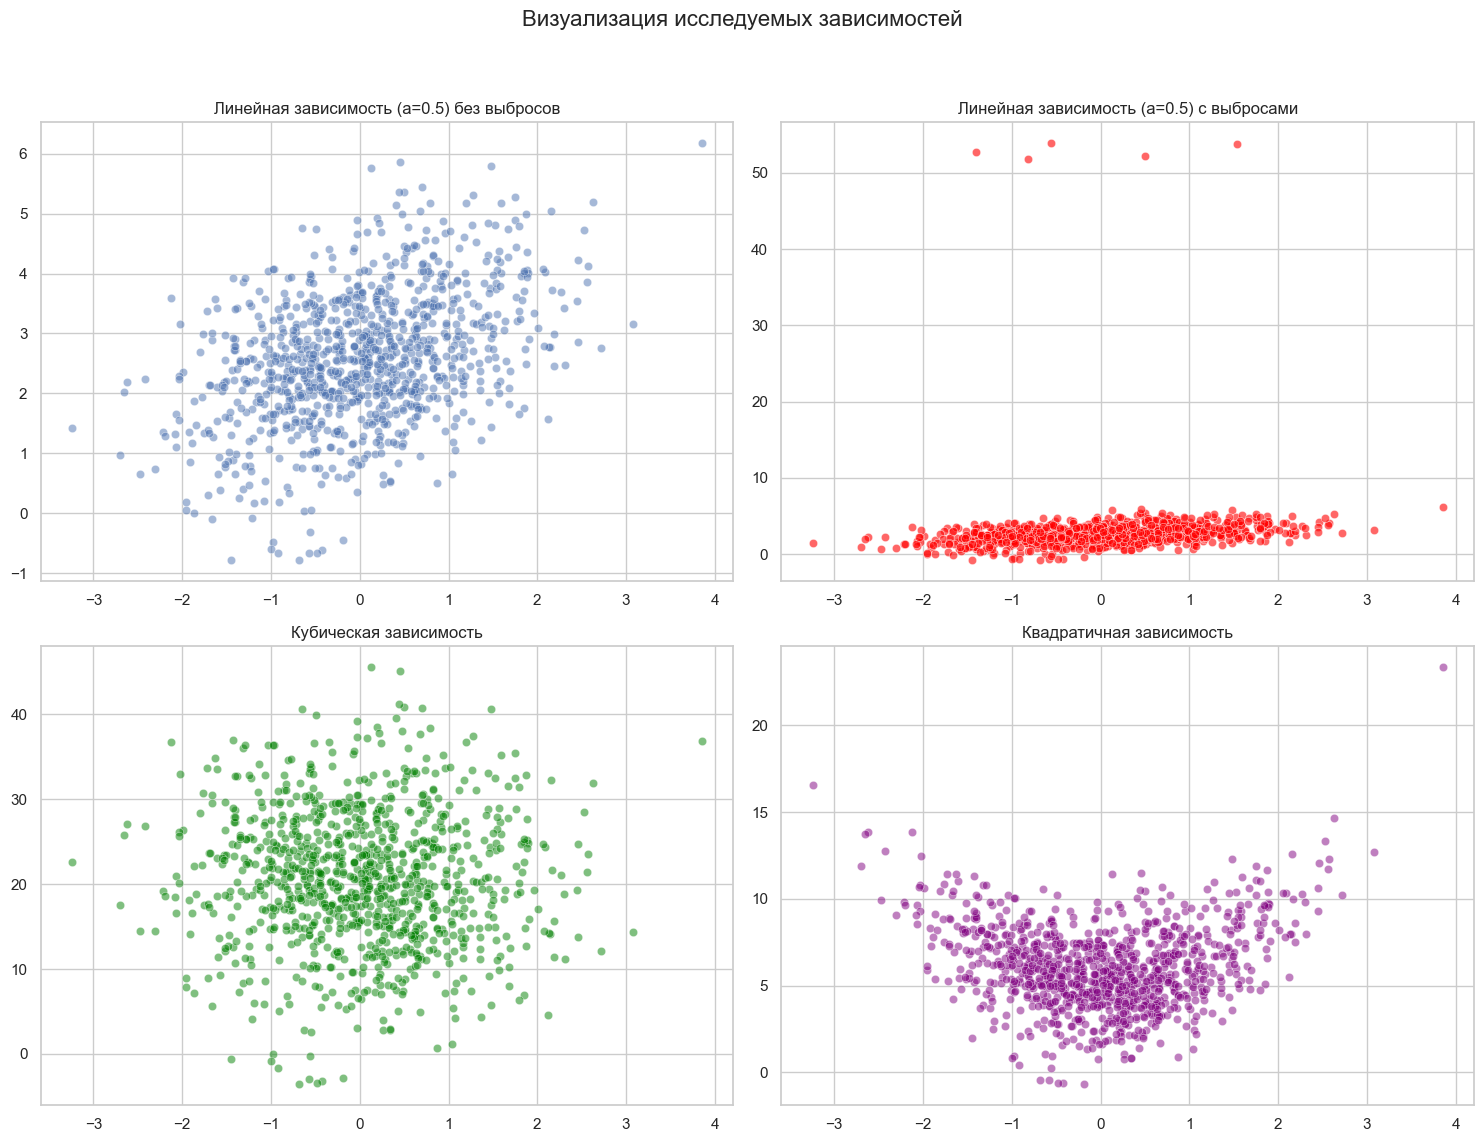

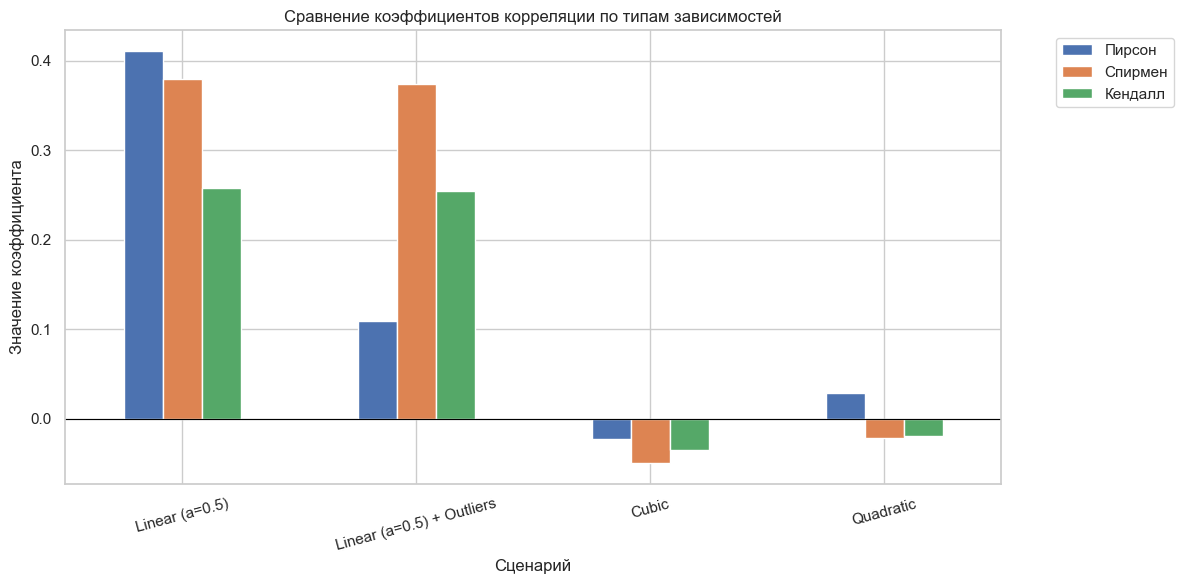

In [ ]:
sns.set_theme(style="whitegrid")

def plot_lab3_visuals(x, y_dict):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Линейная (без выбросов)
    sns.scatterplot(x=x, y=y_dict['Linear (a=0.5)'], ax=axes[0, 0], alpha=0.5)
    axes[0, 0].set_title("Линейная зависимость (a=0.5) без выбросов")
    
    # Линейная (с выбросами)
    sns.scatterplot(x=x, y=y_dict['Linear (a=0.5) + Outliers'], ax=axes[0, 1], alpha=0.6, color='red')
    axes[0, 1].set_title("Линейная зависимость (a=0.5) с выбросами")
    
    # Кубическая
    sns.scatterplot(x=x, y=y_dict['Cubic'], ax=axes[1, 0], alpha=0.5, color='green')
    axes[1, 0].set_title("Кубическая зависимость")
    
    # Квадратичная
    sns.scatterplot(x=x, y=y_dict['Quadratic'], ax=axes[1, 1], alpha=0.5, color='purple')
    axes[1, 1].set_title("Квадратичная зависимость")
    
    plt.suptitle("Визуализация исследуемых зависимостей", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    scenarios = ['Linear (a=0.5)', 'Linear (a=0.5) + Outliers', 'Cubic', 'Quadratic']
    metrics = []

    for sc in scenarios:
        if sc in y_dict:
            r_p, _ = stats.pearsonr(x, y_dict[sc])
            r_s, _ = stats.spearmanr(x, y_dict[sc])
            r_k, _ = stats.kendalltau(x, y_dict[sc])
            metrics.append({'Сценарий': sc, 'Пирсон': r_p, 'Спирмен': r_s, 'Кендалл': r_k})

    df_plot = pd.DataFrame(metrics).set_index('Сценарий')
    
    df_plot.plot(kind='bar', figsize=(12, 6), rot=15)
    plt.title("Сравнение коэффициентов корреляции по типам зависимостей")
    plt.ylabel("Значение коэффициента")
    plt.axhline(0, color='black', linewidth=0.8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_lab3_visuals(X, Y_cases)

### Выводы по лабораторной работе №3

В ходе лабораторной работы было проведено исследование трех коэффициентов корреляции - **Пирсона**, **Спирмена** и **Кендалла** - в различных условиях зависимости и при наличии аномальных значений. 

**Основные итоги:**

1.  **Эффективность методов:**
    * **Коэффициент Пирсона** идеально подходит для обнаружения строго линейных зависимостей в «чистых» данных, но теряет свою эффективность при малейших отклонениях от линейности.
    * **Ранговые коэффициенты (Спирмен, Кендалл)** являются более универсальными, так как успешно фиксируют любые монотонные зависимости (например, кубическую), даже если они не являются линейными.
    

2.  **Робастность (устойчивость):**
    * Эксперимент с выбросами показал, что **коэффициент Пирсона крайне неустойчив**: наличие всего 0.5% аномальных точек приводит к резкому падению его значения (до 70–80%), что может привести к ложноотрицательному результату теста на значимость.
    * **Коэффициенты Кендалла и Спирмена обладают высокой робастностью**, сохраняя стабильные значения (изменение < 6%) при наличии выбросов, что делает их предпочтительными для анализа реальных данных.
    

3.  **Ограничения корреляционного анализа:**
    * Анализ квадратичной зависимости подтвердил, что классические коэффициенты корреляции «слепы» к немонотонным связям. Нулевые значения коэффициентов при наличии явной функциональной связи ($Y=X^2+Z$) доказывают, что **отсутствие корреляции не означает отсутствия зависимости**.